# 03b · K-means clustering — consumer segments

TF-IDF → silhouette to pick k → KMeans → profile each cluster → PCA scatter + radar charts.

In [1]:
import sys, os, ast
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import DATA_PROCESSED, DATA_RESULTS
from analysis.clustering import (
    vectorize, find_optimal_k, fit, cluster_top_terms,
    profile_clusters, label_cluster,
)
from visualization.cluster_viz import plot_pca_scatter, plot_cluster_radar

df = pd.read_csv(DATA_PROCESSED / 'twitter_enriched.csv')
for col in ['flavors', 'pains', 'occasions', 'formats', 'brands']:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
print(f'{len(df)} tweets ready for clustering')

5021 tweets ready for clustering


Silhouette scores: {2: 0.014391651849015736, 3: 0.020282971217998585, 4: 0.020236187200907765, 5: 0.022538084000935786, 6: 0.02226000113495715, 7: 0.020262514965036758}
Best k = 5


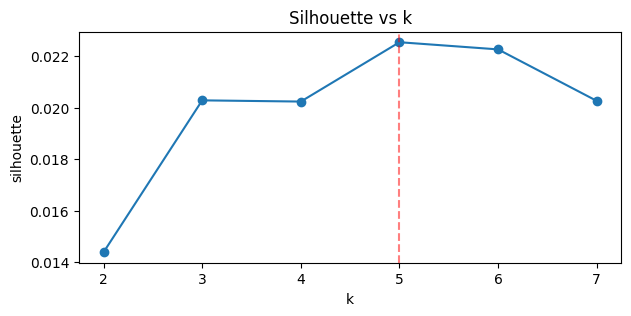

In [2]:
X, vec = vectorize(df['clean_text_no_stop'].fillna(''))
best_k, scores = find_optimal_k(X)
print('Silhouette scores:', scores)
print(f'Best k = {best_k}')

# Quick silhouette plot
plt.figure(figsize=(7, 3))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.5)
plt.xlabel('k'); plt.ylabel('silhouette'); plt.title('Silhouette vs k')
plt.show()

In [3]:
km = fit(X, best_k)
df['cluster'] = km.labels_

top_terms = cluster_top_terms(km, vec)
profile = profile_clusters(df)

# Human labels
cluster_labels = {
    int(row['cluster']): label_cluster(top_terms[int(row['cluster'])], row.to_dict())
    for _, row in profile.iterrows()
}
profile['label'] = profile['cluster'].map(cluster_labels)
profile['top_terms'] = profile['cluster'].map(lambda c: ', '.join(top_terms[int(c)][:6]))
profile.to_csv(DATA_RESULTS / 'cluster_profiles.csv', index=False)
profile

,cluster,size,size_pct,top_flavor,top_pain,top_occasion,top_format,avg_sentiment,pct_positive,label,top_terms
0,4,1827,36.4,coffee,too_thick,morning,shake,0.181,63.9,Morning / Coffee / (too_thick),"eat, protein, day, morning, drink, water"
1,2,1275,25.4,coffee,grainy,morning,shake,0.256,69.1,Morning / Coffee / (grainy),"drink, milk, protein, protein drink, matcha, p..."
2,1,1156,23.0,strawberry,chalky,morning,shake,0.005,43.6,Morning / Strawberry / (chalky),"shake, protein shake, protein, disgusting, str..."
3,0,511,10.2,banana,artificial,morning,shake,0.144,56.9,Morning / Banana / (artificial),"yogurt, greek, greek yogurt, protein, danone, ..."
4,3,252,5.0,coffee,too_thick,morning,yogurt_drink,0.204,63.5,Morning / Coffee / (too_thick),"drinkable, drinkable yogurt, yogurt, morning, ..."


In [4]:
plot_pca_scatter(X, km.labels_, cluster_labels)
plot_cluster_radar(profile, df, cluster_labels)

PosixPath('/home/azril/Personal/Projects/DSAI/NUSFTC/nlp social listening 2/outputs/figures/BONUS_cluster_radar.png')

In [5]:
# Save tweet-level cluster assignments
df[['tweet_id', 'cluster']].to_csv(DATA_RESULTS / 'cluster_assignments.csv', index=False)
print(f'Saved cluster assignments for {len(df)} tweets')

Saved cluster assignments for 5021 tweets
